In [ ]:
import re

def main(file):
    print(f"Leyendo el archivo: {file}...\n")
    uniqueSpecies, reactions = parseChemFile(file)

    print('--- Especies Únicas Encontradas ---')
    for species in uniqueSpecies:
        print(f"- {species}")
        
    print('\n--- Lista de Reacciones ---')
    for i, reaction in enumerate(reactions):
        print(f"R{i+1}: {reaction['description']}")

    # Imprimir detalles de una reacción interesante como ejemplo
    print('\n--- Detalle de una Reacción (Ejemplo) ---')
    if len(reactions) > 0:
        # Cogemos la reacción de disociación como ejemplo
        reaction = reactions[6] 
        print(f"Descripción: {reaction['description']}")
        print(f"Es reversible: {'Sí' if reaction['backwardReaction'] else 'No'}")
        
        for idx in range(len(reaction['lhsSpecies'])):
            print(f"Reactivo (Izq): {reaction['lhsStoichiometricCoeffs'][idx]} {reaction['lhsSpecies'][idx]}")
        for idx in range(len(reaction['rhsSpecies'])):
            print(f"Producto (Der): {reaction['rhsStoichiometricCoeffs'][idx]} {reaction['rhsSpecies'][idx]}")

    return 0

def parseChemFile(file):
    """Parsea el archivo químico y extrae especies y reacciones."""
    with open(file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    uniqueSpecies = []
    reactions = []
    
    for line in lines:
        cleanLine = line.strip()
        # Ignorar líneas vacías o comentarios puros
        if not cleanLine or cleanLine.startswith('%'):
            continue
            
        # Separar la reacción de los datos cinéticos usando el delimitador '|'
        reaction_str = cleanLine.split('|')[0].strip()
        
        # Si la línea queda vacía tras el split, saltar
        if not reaction_str:
            continue
            
        reaction = parseReactionStr(reaction_str)
        
        if reaction not in reactions:
            reactions.append(reaction)
            
        # Extraer especies únicas
        for species in reaction['lhsSpecies'] + reaction['rhsSpecies']:
            if species not in uniqueSpecies:
                uniqueSpecies.append(species)

    return uniqueSpecies, reactions

def parseReactionStr(reactionStr):
    """Parsea el string de la reacción para dividir lados y estequiometría."""
    if '<->' in reactionStr:
        backwardReaction = True
        lhsStr, rhsStr = reactionStr.split('<->')
    elif '->' in reactionStr:
        backwardReaction = False
        lhsStr, rhsStr = reactionStr.split('->')
    else:
        raise ValueError(f"Formato de reacción no válido: {reactionStr}")
    
    lhsSpecies, lhsStoichiometricCoeffs = parseSpeciesStr(lhsStr)
    rhsSpecies, rhsStoichiometricCoeffs = parseSpeciesStr(rhsStr)
    
    reaction = {
        'description': reactionStr,
        'lhsSpecies': lhsSpecies,
        'lhsStoichiometricCoeffs': lhsStoichiometricCoeffs,
        'rhsSpecies': rhsSpecies,
        'rhsStoichiometricCoeffs': rhsStoichiometricCoeffs,
        'backwardReaction': backwardReaction
    }
    return reaction

def parseSpeciesStr(species_string):
    """Parsea el lado de una reacción extrayendo coeficientes y nombres de especies."""
    species_list = []
    coeff_list = []
    
    # Separar por ' + ' (con espacios). Esto evita romper nombres como O2(+,X)
    parts = species_string.strip().split(' + ')
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
        
        # Regex para capturar el coeficiente (entero o decimal) y la especie
        # Captura cosas como "2O(3P)", "0.5O2(X)" o simplemente "e"
        match = re.match(r'^(\d*\.?\d*)(.+)$', part)
        if match:
            coeff_str = match.group(1)
            species = match.group(2).strip()
            
            # Convertir el coeficiente a float si tiene punto decimal, si no a int
            if coeff_str:
                coeff = float(coeff_str) if '.' in coeff_str else int(coeff_str)
            else:
                coeff = 1
            
            if species not in species_list:
                species_list.append(species)
                coeff_list.append(coeff)
            else:
                index = species_list.index(species)
                coeff_list[index] += coeff

    return species_list, coeff_list

if __name__ == "__main__":
    main('oxygen_novib.chem')

Leyendo el archivo: oxygen_novib.chem...

--- Especies Únicas Encontradas ---
- e
- O2(X)
- O2(a1Dg)
- O2(b1Sg+)
- O(3P)
- O(1D)
- O2(A3Su+_C3Du_c1Su-)
- O3(X)
- O2(+,X)
- O(+,gnd)
- O(-,gnd)
- O3(exc)
- wall

--- Lista de Reacciones ---
R1: e + O2(X) <-> e + O2(a1Dg)
R2: e + O2(X) <-> e + O2(b1Sg+)
R3: e + O2(a1Dg) <-> e + O2(b1Sg+)
R4: e + O(3P) <-> e + O(1D)
R5: e + O2(X) <-> e + O2(A3Su+_C3Du_c1Su-)
R6: e + O2(X) -> e + 2O(3P)
R7: e + O2(X) -> e + O(3P) + O(1D)
R8: e + O2(a1Dg) -> e + 2O(3P)
R9: e + O2(a1Dg) -> e + O(3P) + O(1D)
R10: e + O2(b1Sg+) -> e + 2O(3P)
R11: e + O2(b1Sg+) -> e + O(3P) + O(1D)
R12: e + O3(X) -> e + O(3P) + O2(X)
R13: e + O2(X) -> 2e + O2(+,X)
R14: e + O2(a1Dg) -> 2e + O2(+,X)
R15: e + O(3P) -> 2e + O(+,gnd)
R16: e + O(-,gnd) -> 2e + O(3P)
R17: e + O2(X) ->  2e + O(3P) + O(+,gnd)
R18: e + O2(a1Dg) ->  2e + O(3P) + O(+,gnd)
R19: e + O2(X) -> O(-,gnd) + O(3P)
R20: e + O2(a1Dg) -> O(-,gnd) + O(3P)
R21: e + O2(+,X) -> 2O(3P)
R22: e + O2(+,X) -> O(3P) + O(1D)
R23:

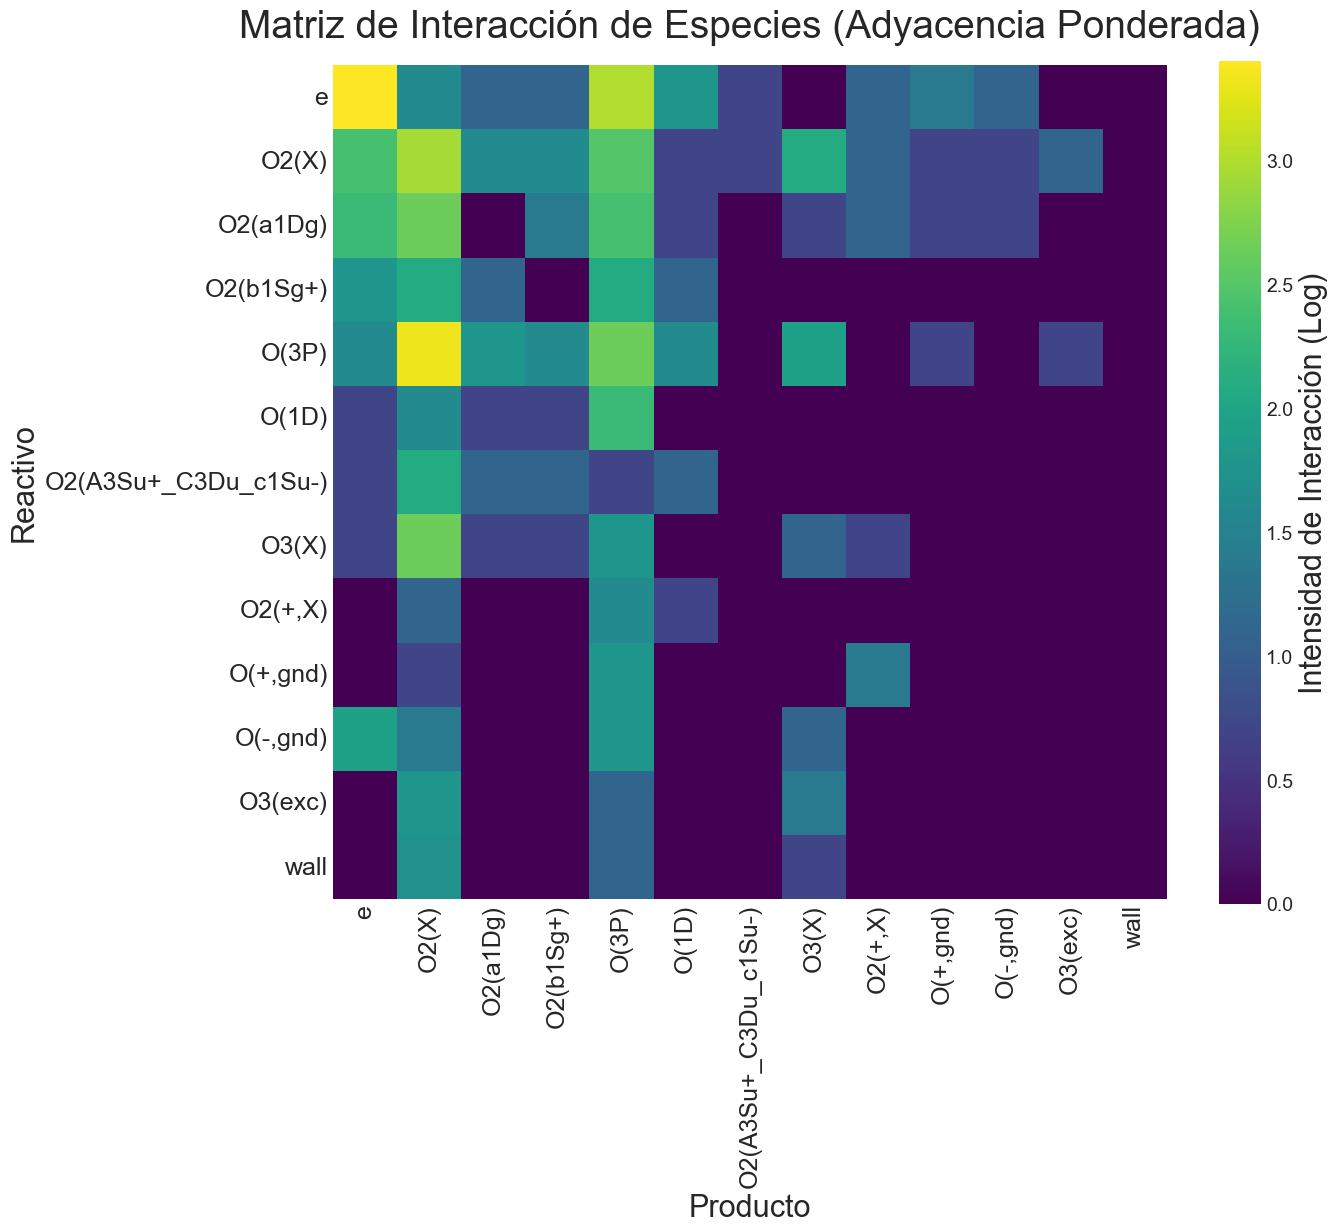

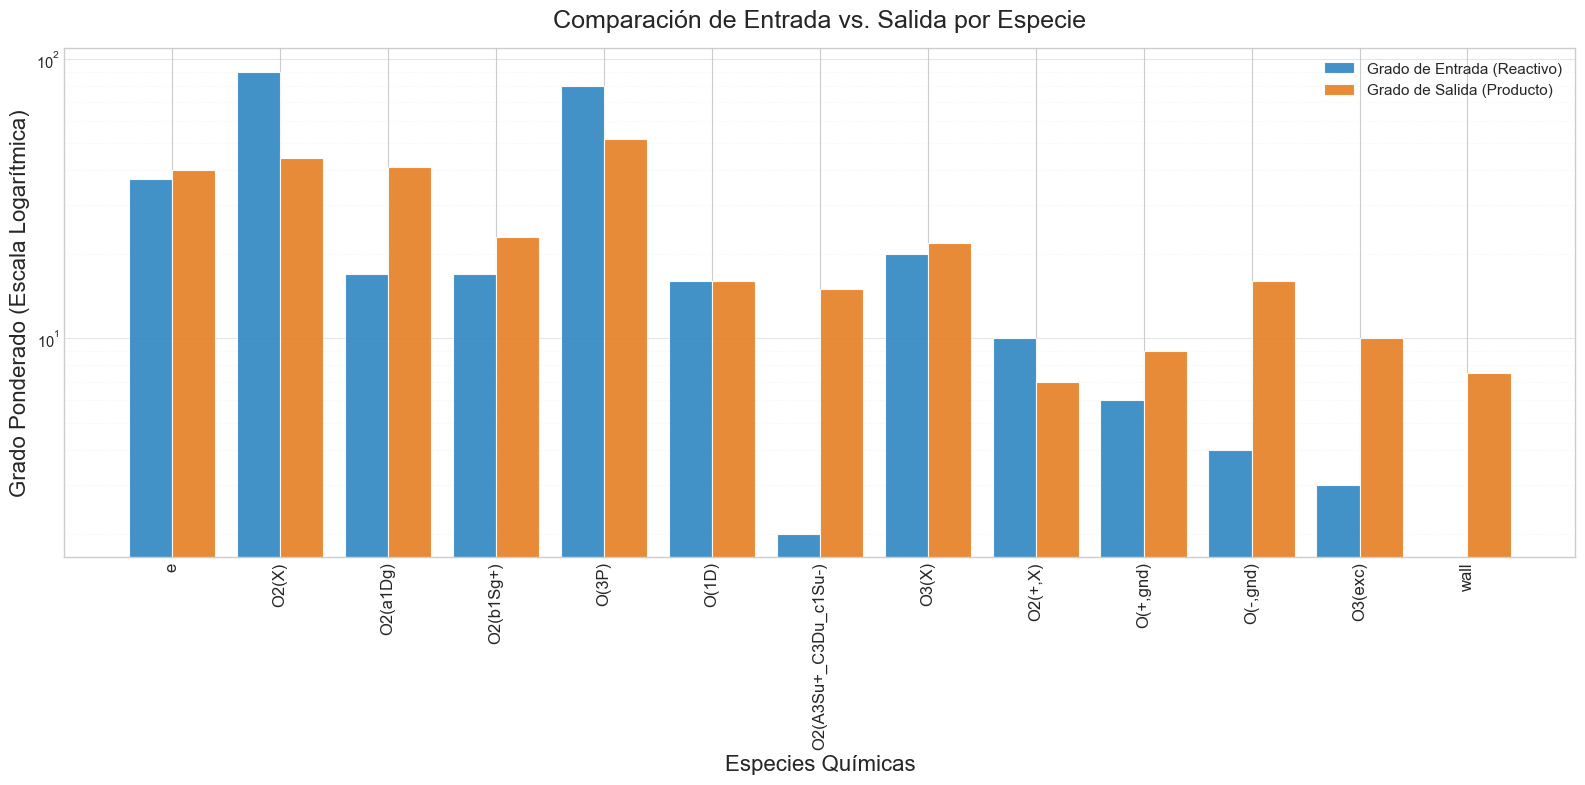

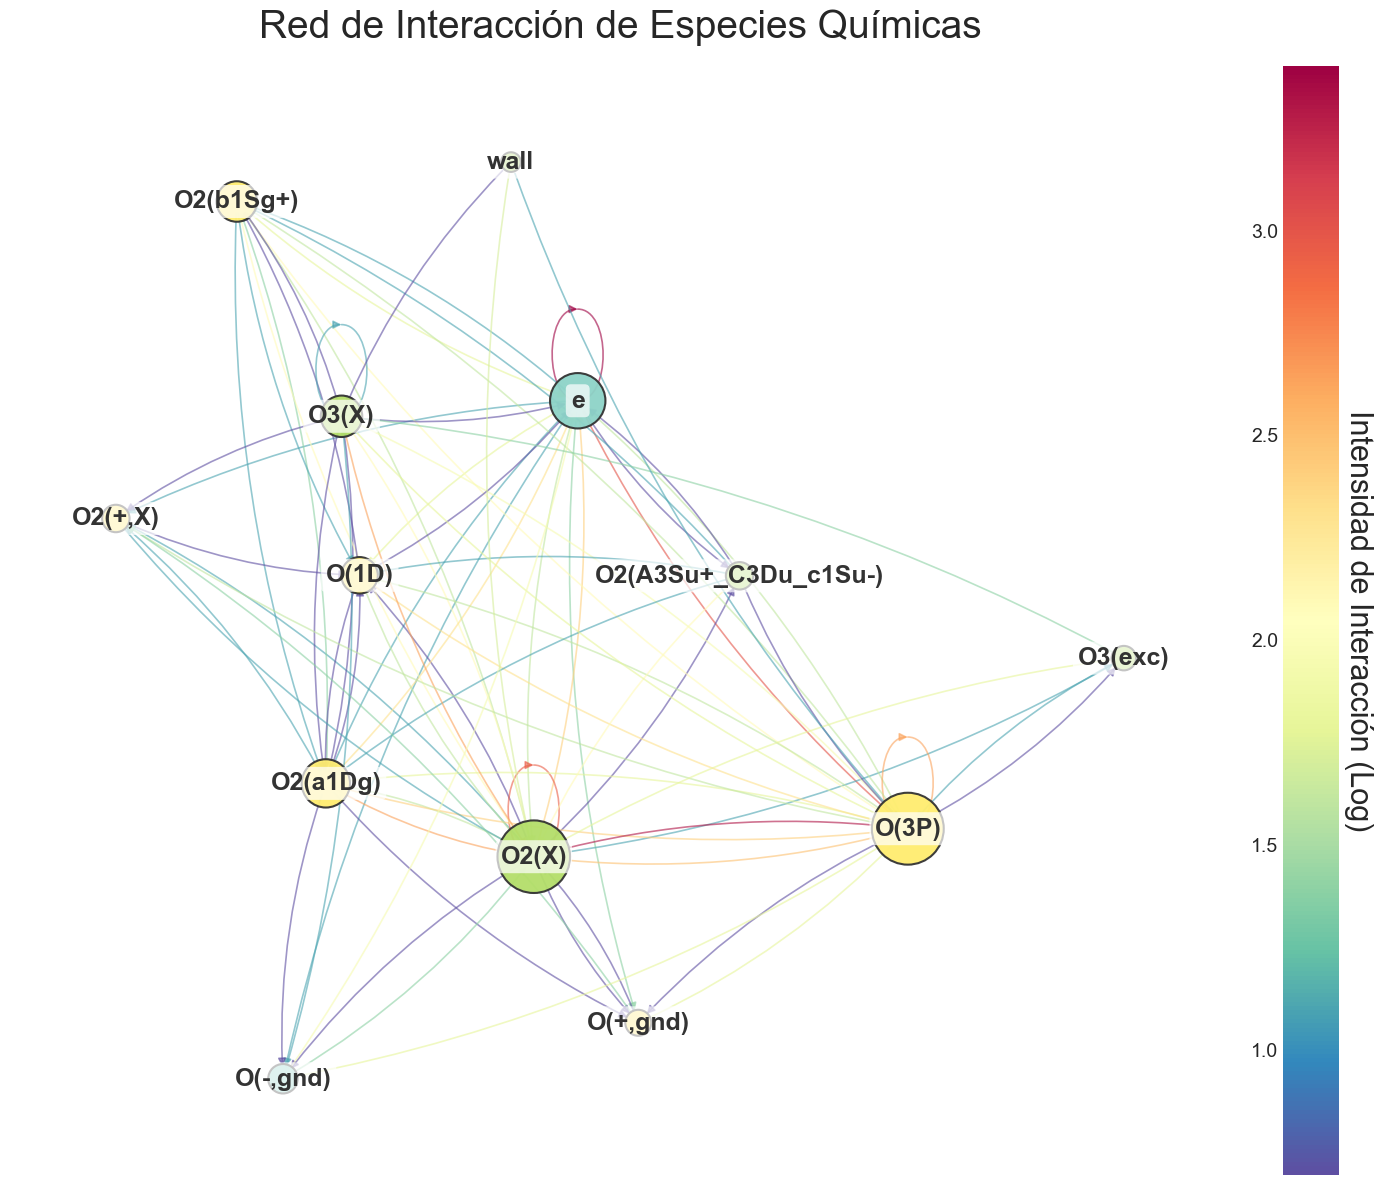

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from networkx.algorithms import community

# --- (Asegúrate de tener definida tu función parseChemFile) ---
uniqueSpecies, reactions = parseChemFile('oxygen_novib.chem')

G = nx.DiGraph()
G.add_nodes_from(uniqueSpecies)

for r in reactions:
    # Sentido directo
    for src in r['lhsSpecies']:
        for dst in r['rhsSpecies']:
            w = r['lhsStoichiometricCoeffs'][r['lhsSpecies'].index(src)] * \
                r['rhsStoichiometricCoeffs'][r['rhsSpecies'].index(dst)]
            if G.has_edge(src, dst): G[src][dst]['weight'] += w
            else: G.add_edge(src, dst, weight=w)
    # Sentido inverso
    if r['backwardReaction']:
        for src in r['rhsSpecies']:
            for dst in r['lhsSpecies']:
                w = r['rhsStoichiometricCoeffs'][r['rhsSpecies'].index(src)] * \
                    r['lhsStoichiometricCoeffs'][r['lhsSpecies'].index(dst)]
                if G.has_edge(src, dst): G[src][dst]['weight'] += w
                else: G.add_edge(src, dst, weight=w)

# --- 3. VISUALIZACIONES ---

# --- FUNCIÓN DE FORMATO PARA NOMBRES LARGOS ---
def formatear_nombre(nombre):
    if 'O2(A3Su' in nombre:
        return nombre.replace(',', ',\n') 
    return nombre

orden_nodos = list(G.nodes)
etiquetas_display = [formatear_nombre(n) for n in orden_nodos]

# --- BLOQUE: MATRIZ DE ADYACENCIA PROFESIONAL ---
matriz_adyacencia = nx.to_numpy_array(G, nodelist=orden_nodos)

df_adj = pd.DataFrame(np.log1p(matriz_adyacencia), 
                      index=orden_nodos, 
                      columns=orden_nodos)

# Ajuste de tamaño para acomodar las etiquetas
plt.figure(figsize=(14, 12))
ax_heatmap = sns.heatmap(df_adj, 
            cmap='viridis',      
            xticklabels=etiquetas_display,  
            yticklabels=etiquetas_display,  
            cbar=True,
            square=True) 

# Ajuste de fuente de la barra de intensidad
cbar = ax_heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Intensidad de Interacción (Log)', fontsize=22)

plt.title('Matriz de Interacción de Especies (Adyacencia Ponderada)', fontsize=28, pad=20)
plt.xlabel('Producto', fontsize=22)
plt.ylabel('Reactivo', fontsize=22)

# Etiquetas a tamaño 13
plt.xticks(rotation=90, fontsize=18) 
plt.yticks(rotation=0, fontsize=18)
plt.tight_layout()
plt.show()


# 1. Cálculo de grados (Entrada y Salida)
grado_entrada = []
grado_salida = []
for i in range(len(orden_nodos)):
    g_in = np.sum(matriz_adyacencia[:, i]) - matriz_adyacencia[i,i]
    g_out = np.sum(matriz_adyacencia[i, :]) - matriz_adyacencia[i,i]
    grado_entrada.append(g_in)
    grado_salida.append(g_out)

# --- BLOQUE: BARRAS AGRUPADAS CON LOG ---
x = np.arange(len(orden_nodos))  
width = 0.4  

plt.figure(figsize=(16, 8))
plt.bar(x - width/2, grado_entrada, width, label='Grado de Entrada (Reactivo)', color='#2E86C1', alpha=0.9, log=True)
plt.bar(x + width/2, grado_salida, width, label='Grado de Salida (Producto)', color='#E67E22', alpha=0.9, log=True)

plt.xlabel('Especies Químicas', fontsize=16)
plt.ylabel('Grado Ponderado (Escala Logarítmica)', fontsize=16)
plt.title('Comparación de Entrada vs. Salida por Especie', fontsize=18, pad=15)

plt.xticks(x, etiquetas_display, rotation=90, fontsize=12)
plt.xlim(-1, len(orden_nodos)) 

plt.legend(fontsize=11)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.5)
plt.grid(axis='y', which='minor', linestyle=':', alpha=0.2)

plt.tight_layout()
plt.show()


# C. Proyección de la Red
pos = nx.kamada_kawai_layout(G)
grado_total = [grado_entrada[i] + grado_salida[i] for i in range(len(orden_nodos))]
node_sizes = [50 + 20 * g for g in grado_total] 
np.save('grado_total_oxigeno_novib.npy', grado_total)

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
weights_log = np.log1p(weights) 

comunidades = community.louvain_communities(G, weight='weight', seed=123)
mapa_comunidades = {nodo: i for i, comm in enumerate(comunidades) for nodo in comm}
node_colors = [mapa_comunidades[nodo] for nodo in G.nodes()]

plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(14, 12), dpi=100) 

nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color=weights_log,
                       edge_cmap=plt.cm.Spectral_r, width=1.2, alpha=0.6,
                       arrowsize=12, arrowstyle='-|>', connectionstyle="arc3,rad=0.1") 

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,   
                       cmap=plt.cm.Set3, edgecolors='#333333', linewidths=1.5, alpha=0.95)


pos_labels = {k: (v[0], v[1]) for k, v in pos.items()} 
etiquetas_grafo = {nodo: formatear_nombre(nodo) for nodo in G.nodes()}

labels = nx.draw_networkx_labels(G, pos_labels, labels=etiquetas_grafo, ax=ax,
                                 font_size=18, font_family='sans-serif', font_weight='bold', font_color='#333333')

for t in labels.values():
    t.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

# 6. BARRA DE COLOR Y DETALLES FINALES
sm = plt.cm.ScalarMappable(cmap=plt.cm.Spectral_r, norm=plt.Normalize(vmin=min(weights_log), vmax=max(weights_log)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)


cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.tick_params(labelsize=14) 

cbar.set_label('Intensidad de Interacción (Log)', rotation=270, labelpad=25, fontsize=22)
cbar.outline.set_visible(False)

ax.set_title("Red de Interacción de Especies Químicas", fontsize=28, pad=20)
ax.axis('off') 

plt.tight_layout()
plt.show()

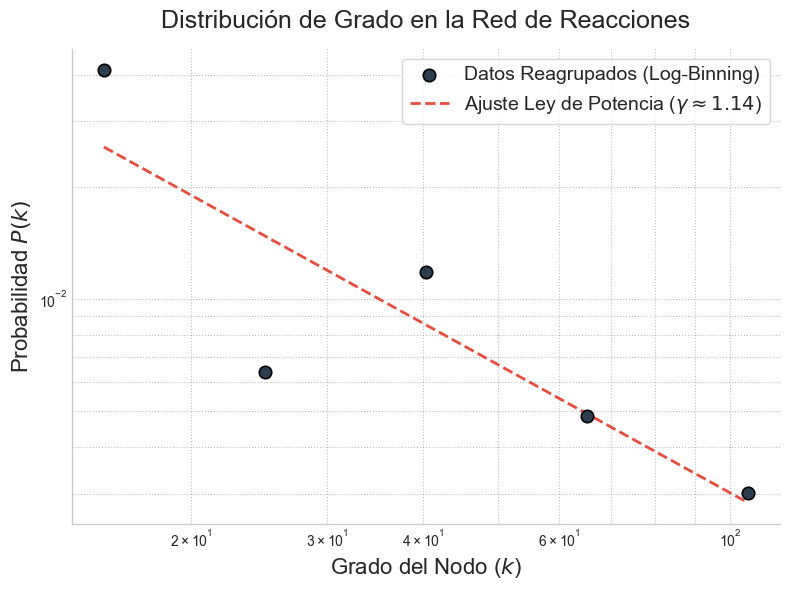

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- FUNCIÓN DE LOG-BINNING  ---
def logarithmic_binning(grados, n_bins=15): 
    grados = np.array(grados)
    grados = grados[grados > 0]
    min_exp, max_exp = np.log10(min(grados)), np.log10(max(grados))
    bins = np.logspace(min_exp, max_exp, num=n_bins)
    counts, edges = np.histogram(grados, bins=bins, density=False)
    bin_widths = np.diff(edges)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])
    density = counts / (bin_widths * len(grados))
    mask = density > 0
    return bin_centers[mask], density[mask]

# 1. Procesamiento de datos
x_binned, y_binned = logarithmic_binning(grado_total, n_bins=7)

# 2. Ajuste Lineal en espacio logarítmico
log_x, log_y = np.log10(x_binned), np.log10(y_binned)
def linear_model(x, m, c): return m * x + c
popt, _ = curve_fit(linear_model, log_x, log_y)
gamma = -popt[0] # El exponente de la ley de potencias

# --- GRÁFICA PROFESIONAL ---
plt.figure(figsize=(8, 6))

# Dibujar solo los datos agrupados
plt.scatter(x_binned, y_binned, 
            color='#2c3e50',     
            s=80, 
            edgecolors='black', 
            linewidths=1.2,
            label='Datos Reagrupados (Log-Binning)',
            zorder=3)

# Línea de ajuste
x_line = np.logspace(np.log10(min(x_binned)), np.log10(max(x_binned)), 100)
y_line = (10**popt[1]) * (x_line**popt[0])
plt.plot(x_line, y_line, 
         color='#e74c3c',        
         linestyle='--', 
         linewidth=2, 
         label=rf'Ajuste Ley de Potencia ($\gamma \approx {gamma:.2f}$)',
         zorder=2)

# Configuración de Ejes Estilo Paper
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Grado del Nodo ($k$)', fontsize=16)
plt.ylabel(r'Probabilidad $P(k)$', fontsize=16)
plt.title('Distribución de Grado en la Red de Reacciones', fontsize=18, pad=15)

# Mejorar la rejilla y el marco
plt.grid(True, which="both", ls=":", alpha=0.5, color='gray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Leyenda y Anotación técnica
plt.legend(frameon=True, loc='upper right', fontsize=14)
plt.tight_layout()

plt.show()